### Рубежный контроль №1 

#### Борисова К.А. ИУ5-62Б

##### Задача №1.
Для заданного набора данных проведите корреляционный анализ. В случае наличия пропусков в данных удалите строки или колонки, содержащие пропуски. Сделайте выводы о возможности построения моделей машинного обучения и о возможном вкладе признаков в модель.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use('default')
sns.set_theme()
%matplotlib inline

df = pd.read_csv('heart.csv')
print(f"Размер данных: {df.shape}")
df.head()

Размер данных: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [2]:
# Проверка пропусков
print("Пропуски в данных:")
print(df.isnull().sum())


Пропуски в данных:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


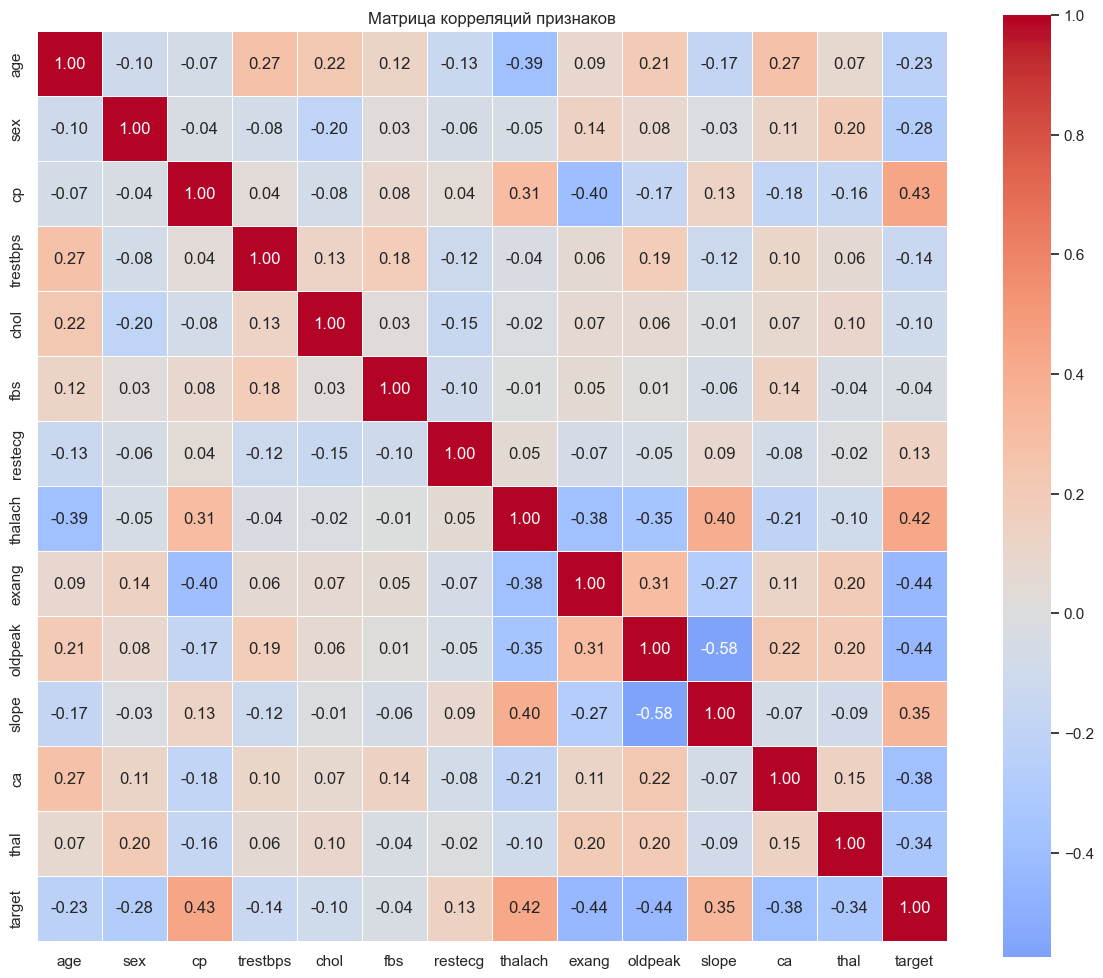


Корреляция с целевой переменной (target):
target      1.000000
cp          0.434854
thalach     0.422895
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.099966
trestbps   -0.138772
age        -0.229324
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.438441
Name: target, dtype: float64

Топ-5 сильных корреляций между признаками:
target   cp         0.434854
cp       target     0.434854
target   thalach    0.422895
thalach  target     0.422895
         slope      0.395308
slope    thalach    0.395308
target   slope      0.345512
slope    target     0.345512
oldpeak  exang      0.310844
exang    oldpeak    0.310844
dtype: float64


In [4]:
corr_matrix = df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Матрица корреляций признаков')
plt.tight_layout()
plt.show()

target_corr = corr_matrix['target'].sort_values(ascending=False)
print("\nКорреляция с целевой переменной (target):")
print(target_corr)

corr_pairs = corr_matrix.unstack().sort_values(kind='quicksort', ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1] 
print("\n5 сильных корреляций между признаками:")
print(corr_pairs.head(10))

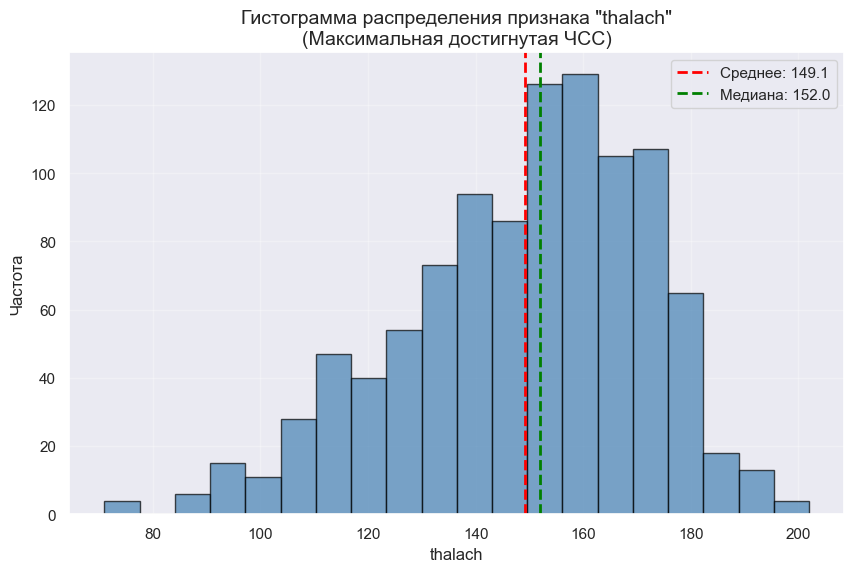


Статистика для 'thalach':
Среднее: 149.11
Медиана: 152.00
Стандартное отклонение: 23.01
Асимметрия: -0.51


In [6]:

column_name = 'thalach'
data_column = df[column_name]

plt.figure(figsize=(10, 6))
plt.hist(data_column, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
plt.xlabel(column_name, fontsize=12)
plt.ylabel('Частота', fontsize=12)
plt.title(f'Гистограмма распределения признака "{column_name}"\n(Максимальная достигнутая ЧСС)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.axvline(data_column.mean(), color='red', linestyle='dashed', linewidth=2, label=f'Среднее: {data_column.mean():.1f}')
plt.axvline(data_column.median(), color='green', linestyle='dashed', linewidth=2, label=f'Медиана: {data_column.median():.1f}')
plt.legend()
plt.show()

print(f"\nСтатистика для '{column_name}':")
print(f"Среднее: {data_column.mean():.2f}")
print(f"Медиана: {data_column.median():.2f}")
print(f"Стандартное отклонение: {data_column.std():.2f}")
print(f"Асимметрия: {data_column.skew():.2f}")

#### Вывод: 
В ходе лабораторной работы проведен корреляционный анализ данных о сердечных заболеваниях. Обнаружены значимые корреляции с целевой переменной и депрессия ST (oldpeak). В базе данных отсутствовали пропуски. Построена гистограмма признака thalach, показавшая распределение, близкое к нормальному. 